<a href="https://colab.research.google.com/github/JohnnySolo/Data-Analysis-Project---Hybrid-Cyber-Threat-Detection/blob/main/02_EDA_and_Inference.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Exploratory Data Analysis

For this notebook, we will use an industry-standard methodology adapted from Splunk called the PEAK Threat Hunting Framework.

PEAK stands for Prepare, Execute, and Act (with Knowledge). In the cybersecurity world, doing Exploratory Data Analysis (EDA) is referred to as a "Baseline Hunt". The goal isn't just to make pretty charts; the goal is to establish a mathematical baseline of what "normal" (Benign) traffic looks like, so we could clearly identify the mathematical signature of a cyberattack.

## Prepare: Environment & Data Profiling

Before looking for attacks, we need to set the stage and understand the shape of our data.

* Load the Data: Read the clean_cyber_data.parquet file we created in Notebook 1.

* The Target Variable: We'll count the distribution of our Label column.

  Note: It's plausible we'll observe a case of class imbalance (millions of Benign rows vs. a smaller number of Botnet and Infiltration rows). This imbalance is a crucial piece of knowledge that will dictate how we evaluate our machine learning models later.

### Step 1: Load The Data

In [2]:
# Mount your Google Drive
from google.colab import drive
drive.mount('/content/drive')

# Install PySpark (since this is a new notebook environment)
!pip install pyspark

# Initialize the Spark Session
from pyspark.sql import SparkSession
spark = SparkSession.builder.appName("Cyber_EDA").getOrCreate()

# 1. Defining the path to the folder containing the data files
base_path = "/content/drive/MyDrive/Projects/Hybrid Cyber Threat Detection/"

# 2. Using the wildcard (*) to explicitly tell PySpark to read all the 'part-' files
files_to_load = base_path + "part-*.parquet"

# 3. Load and combine the 4 files into a single DataFrame
df_clean = spark.read.parquet(files_to_load)

# 4. Verify the combined data loaded correctly
print("Total rows loaded from all 4 files:", df_clean.count())

Mounted at /content/drive
Total rows loaded from all 4 files: 1428508


### Step 2: Profile the Target Variable

Exact Label Counts from all 4 files:
+-------------+-------+
|Label        |count  |
+-------------+-------+
|Benign       |1123385|
|Bot          |245601 |
|Infilteration|59522  |
+-------------+-------+



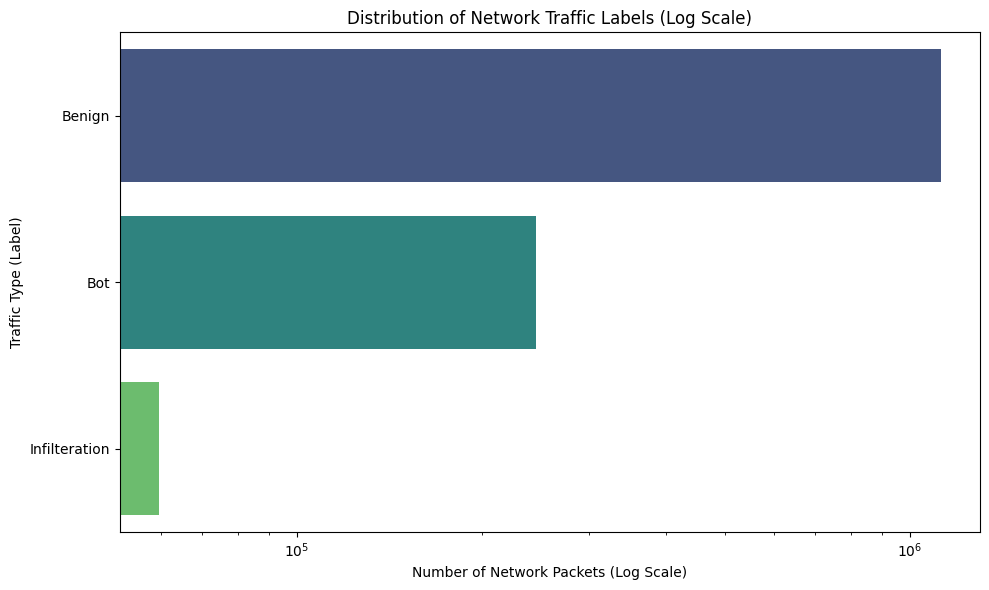

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

# Count the distribution across the combined 4 files
label_distribution = df_clean.groupBy("Label") \
                             .count() \
                             .orderBy("count", ascending=False)

# Show the exact numbers in text format
print("Exact Label Counts from all 4 files:")
label_distribution.show(truncate=False)

# Convert the summary table to Pandas for visualization
pdf_labels = label_distribution.toPandas()

# Plot the distribution
plt.figure(figsize=(10, 6))
sns.barplot(x='count', y='Label', data=pdf_labels, hue='Label', legend=False, palette='viridis')
plt.title('Distribution of Network Traffic Labels (Log Scale)')
plt.xlabel('Number of Network Packets (Log Scale)')
plt.ylabel('Traffic Type (Label)')
plt.xscale('log')
plt.tight_layout()
plt.show()

## Execute: Visual Baselining (The Core EDA)

This is where we explore the 80+ network features to find visual differences between safe traffic (Benign) and cyber threats (Bot & Infilteration).

* **Tree-Based Feature Importance (Pre-screening)**

  Before we do any analysis, we will fit a lightweight, preliminary decision tree to the data to plot overall and label-wise feature importance.

  * <u>The Goal</u>: This gives us a quick, mathematical ranking of which features matter the most when trying to separate Botnets and Infiltration from normal traffic, guiding exactly which features we should analyze and build our hypotheses accordingly.

* **Categorical Profiling (Ports & Protocols)**

  Network traffic flows through specific logical "doors" (ports) and uses specific rules (protocols) - Our first step is to analyze features like `Dst Port` and `Protocol`.
  
  * <u> The Goal</u>: We want to see the most accessed logical ports and identify if our Botnet or Infiltration attacks are trying to communicate over unusual channels compared to the baseline benign traffic.

* **Continuous Variable Distributions (Behavioral Analysis)**

  This is where we look at the actual shape of the traffic using features like `Flow Duration`, `Flow Bytes/s`, and `Packet Length Std`. We will use boxplots and violin plots to compare the distributions of these continuous variables across our three labels.
  
  * <u>The Goal</u>: We are looking for behavioral signatures. For example, Botnets often exhibit highly repetitive, automated packet sizes (low variance), while Infiltration attacks might have exceptionally long flow durations as they slowly and quietly try to steal data.

* **Feature Correlation Analysis**

  The dataset contains roughly 80 features, but many of them could be highly correlated and then redundant. We will generate overall and label-wise feature correlation matrices.
  
  * <u>The Goal</u>: Identifying and eliminating redundant features reduces mathematical noise and computational complexity, which is a critical step before feeding data into our algorithms.

-----

### Step 1: Tree-Based Feature Importance (Pre-screening)

In cybersecurity data science (and in our case as well), datasets often contain dozens or hundreds of raw network telemetry features. Manually exploring every single variable is highly inefficient and risks missing critical indicators of compromise. To streamline our Exploratory Data Analysis (EDA), we utilize an industry-standard technique known as **Automated Feature Pre-Screening**.

Studies have demonstrated that identifying and isolating relevant features from the CSE-CIC-IDS2018 dataset significantly enhances threat detection accuracy, improves processing speed, and reduces model complexity [[1]](https://https://www.mdpi.com/2673-9585/5/1/6). To achieve this, we will fit a lightweight Random Forest algorithm to a sample of our data. Rather than predicting attacks right now, we are using the algorithm to calculate the mathematical "Signal Strength" (Feature Importance) of all 80+ columns.

This automated pre-screening acts as our compass. It will reveal the top 10 most critical network behaviors separating Benign traffic from Infiltration and Botnet attacks, allowing us to focus our subsequent visual analysis and formal statistical inference tests exclusively on the features that actually matter.

Running algorithmic feature pre-screening (Top 20 for Orthogonal Selection)...


/tmp/ipykernel_2074/255366363.py:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=importance_df, palette='magma')


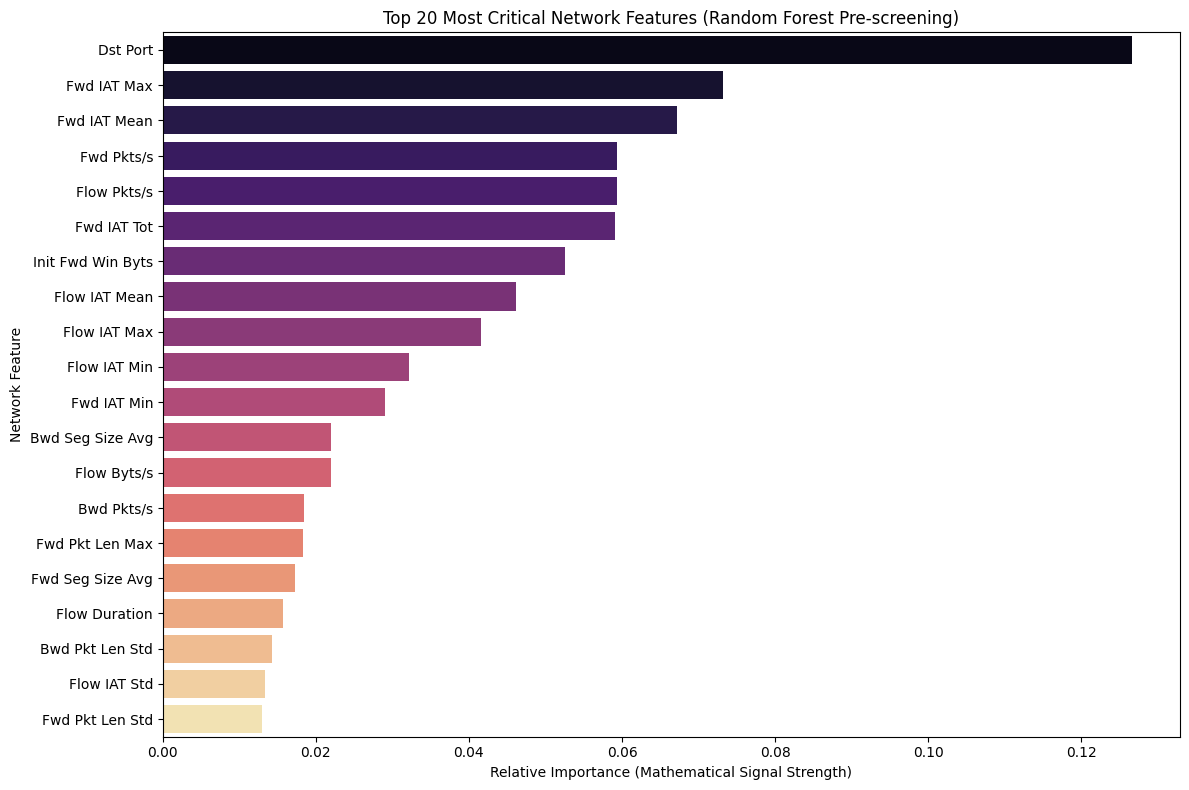


Top 20 Features to categorize:
- Dst Port (Score: 0.1266)
- Fwd IAT Max (Score: 0.0732)
- Fwd IAT Mean (Score: 0.0672)
- Fwd Pkts/s (Score: 0.0594)
- Flow Pkts/s (Score: 0.0593)
- Fwd IAT Tot (Score: 0.0590)
- Init Fwd Win Byts (Score: 0.0526)
- Flow IAT Mean (Score: 0.0461)
- Flow IAT Max (Score: 0.0415)
- Flow IAT Min (Score: 0.0322)
- Fwd IAT Min (Score: 0.0291)
- Bwd Seg Size Avg (Score: 0.0220)
- Flow Byts/s (Score: 0.0219)
- Bwd Pkts/s (Score: 0.0184)
- Fwd Pkt Len Max (Score: 0.0183)
- Fwd Seg Size Avg (Score: 0.0173)
- Flow Duration (Score: 0.0157)
- Bwd Pkt Len Std (Score: 0.0143)
- Flow IAT Std (Score: 0.0133)
- Fwd Pkt Len Std (Score: 0.0130)


In [3]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

print("Running algorithmic feature pre-screening (Top 20 for Orthogonal Selection)...")

# 1. Take a 5% sample of the full clean dataset to run locally for speed
df_rf_sample = df_clean.sample(fraction=0.05, seed=42).toPandas()

# 2. Separate our features (X) from our target (y)
X = df_rf_sample.select_dtypes(include=[np.number])
y = df_rf_sample['Label']

# 3. Convert our text labels (Benign, Bot, Infiltration) into numbers
le = LabelEncoder()
y_encoded = le.fit_transform(y)

# 4. Train a quick Random Forest to evaluate the data
rf = RandomForestClassifier(n_estimators=50, random_state=42, n_jobs=-1)
rf.fit(X, y_encoded)

# 5. Extract and rank the importance of all features, keeping the Top 20
importances = rf.feature_importances_
importance_df = pd.DataFrame({'Feature': X.columns, 'Importance': importances})
importance_df = importance_df.sort_values(by='Importance', ascending=False).head(20)

# 6. Plot the Top 20 Features
plt.figure(figsize=(12, 8))
sns.barplot(x='Importance', y='Feature', data=importance_df, palette='magma')
plt.title('Top 20 Most Critical Network Features (Random Forest Pre-screening)')
plt.xlabel('Relative Importance (Mathematical Signal Strength)')
plt.ylabel('Network Feature')
plt.tight_layout()
plt.show()

# Print the exact list to make it easier for you to pick categories
print("\nTop 20 Features to categorize:")
for idx, row in importance_df.iterrows():
    print(f"- {row['Feature']} (Score: {row['Importance']:.4f})")

#### Pre-Screening Results & Strategic Focus

The Random Forest feature importance extraction successfully isolated critical network behaviors. However, to prevent multicollinearity, we applied an orthogonal selection strategy across distinct behavioral categories:

1. **The Dominance of Logical Ports**: `Dst Port` (Destination Port) is by far the strongest predictor in the dataset.

    This mathematically validates that attackers utilize non-standard ports (e.g., 8080) or hijack standard ones (443) to establish Command and Control (C2) or exfiltrate data.

2. **Orthogonal Behavioral Pillars**: Our final selection targets 8 independent pillars:
    * Time (`Fwd IAT Max`, `Flow Duration`)
    * Velocity (`Fwd Pkts/s`, `Bwd Pkts/s`)
    * Volume (`Bwd Seg Size Avg`)
    * Variance (`Fwd Pkt Len Std`, `Bwd Pkt Len Std`).

    Although it means not choosing the top features, it's a strategic decision as we aspire to cover as much of information without using severley correlated features (that would have happened if we just chosed the top 8 features).

3. **Timing Over Volume**: The results reveals a crucial behavioral signature. the difference between safe traffic and these specific cyber threats lies in the rhythm, speed, and latency of the connections, rather than the raw volume of bytes transferred.

Based on these insights, our exploratory analysis will profile these orthogonal categories to build a comprehensive, multi-dimensional signature for each threat.

### Methodology for the Rest of the EDA (The "Execute" Plan)

In the cybersecurity industry, when an algorithm tells us that "timing" and "ports" are the most important factors, we don't just generate dozens of charts. We use targeted statistical summaries to build strict mathematical profiles for each traffic type.

Here is our methodology for the remainder of the EDA phase:

* **Step 2.1: Categorical Profiling (The "Where")**: We will group the data by `Dst Port` and `Label` to calculate exact frequency distributions. This will definitively tell us if Botnets are using isolated communication channels while Infiltration attacks blend into standard web ports.

* **Step 2.2: Statistical Summaries of Behavioral Metrics (The "How")**: Because 8 of our top features are continuous numerical variables based on time (IAT and Pkts/s), relying purely on visualizations like scatter plots will be too messy and computationally heavy. Instead, the industry standard is to generate a comprehensive statistical summary matrix (calculating the Mean, Median, Standard Deviation, and 75th Percentile) for these top timing features, grouped by traffic type. This gives us hard numbers to define what a "normal" connection speed looks like versus an "attack" speed.

* **Step 2.3: Targeted Visual Confirmation**: We will only use visualizations (like log-scaled boxplots) for the top 2 or 3 continuous features where the statistical summary shows the most extreme variance. This provides a clean visual aid for stakeholders without cluttering the notebook.

* **Step 2.4: Feature Correlation (Collinearity Check)**: Many timing features are redundant (e.g., Fwd IAT Max and Flow IAT Max likely mirror each other). We will generate a correlation matrix specifically for our top features to identify and plan to drop redundant columns before the machine learning phase.

### Step 2: Continuous Variable Distributions (Behavioral Analysis)

#### Step 2.1: Categorical Profiling (Ports & Protocols)

Extracting Top Destination Ports...


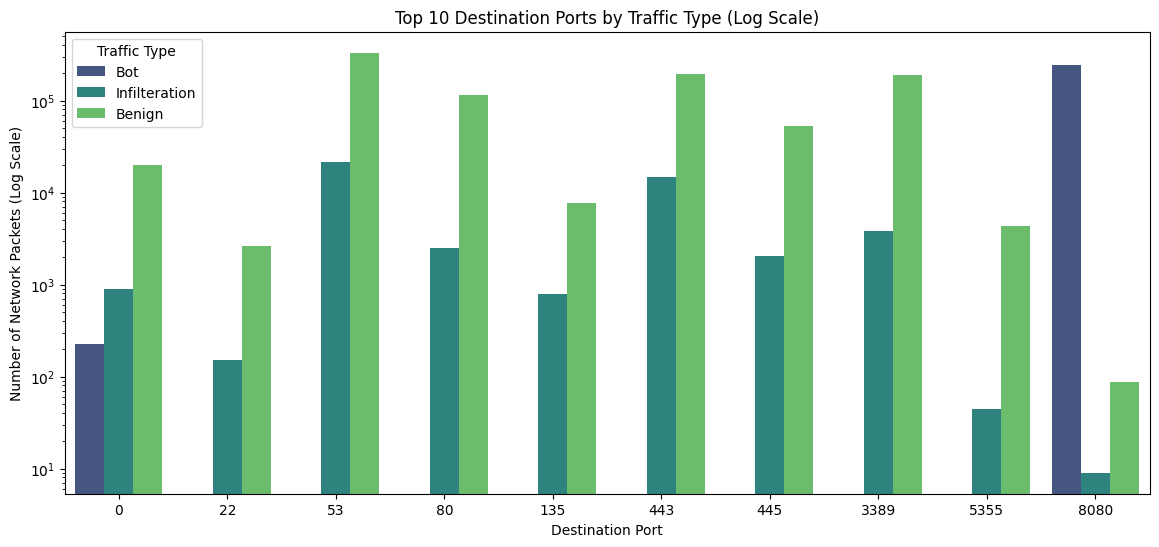

Extracting Network Protocols...


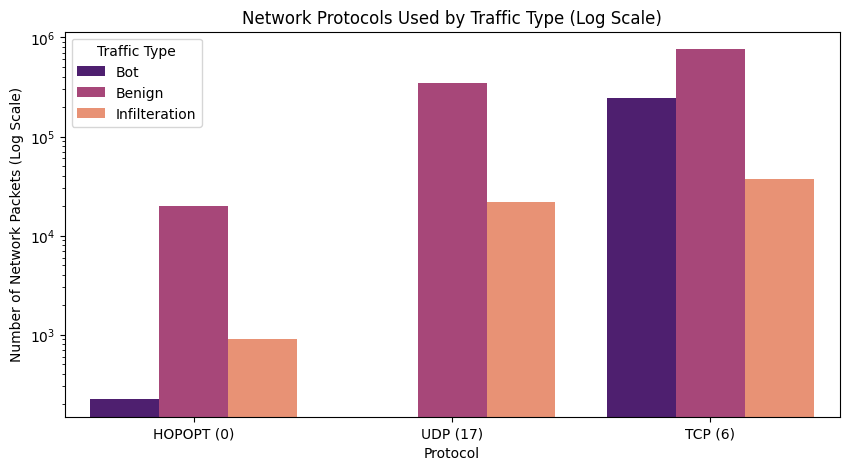

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns
from pyspark.sql import functions as F

# --- PART 1: DESTINATION PORT ANALYSIS ---
print("Extracting Top Destination Ports...")

# 1. Find the top 10 most heavily used ports overall
top_ports_df = df_clean.groupBy("Dst Port") \
                         .count() \
                         .orderBy(F.desc("count")) \
                         .limit(10) \
                         .toPandas() # Convert the PySpark DataFrame into a Pandas DataFrame for easier manipulation and plotting
top_port_list = top_ports_df['Dst Port'].tolist() # Turn the column type to a list instead of it's current one-dim df type.

# 2. Filter data to only include these top ports, then group by Port and Label
port_label_dist = df_clean.filter(F.col("Dst Port").isin(top_port_list)) \
                                  .groupBy("Dst Port", "Label") \
                                  .count() \
                                  .toPandas()

# 3. Plot the Port Distribution
plt.figure(figsize=(14, 6))
sns.barplot(data=port_label_dist, x="Dst Port", y="count", hue="Label", palette="viridis")
plt.yscale("log") # Log scale because Benign traffic dwarfs attack traffic
plt.title("Top 10 Destination Ports by Traffic Type (Log Scale)")
plt.xlabel("Destination Port")
plt.ylabel("Number of Network Packets (Log Scale)")
plt.legend(title="Traffic Type")
plt.show()


# --- PART 2: PROTOCOL ANALYSIS ---
print("Extracting Network Protocols...")

# 1. Group by Protocol and Label
protocol_dist = df_clean.groupBy("Protocol", "Label").count().toPandas() # Label = Our target (attack label)

# 2. Map standard IANA protocol numbers to names for readability
# 0 = IPv6 Hop-by-Hop Option, 6 = TCP, 17 = UDP
protocol_map = {0: "HOPOPT (0)", 6: "TCP (6)", 17: "UDP (17)"}
protocol_dist["Protocol_Name"] = protocol_dist["Protocol"].map(protocol_map).fillna(protocol_dist["Protocol"].astype(str))

# 3. Plot the Protocol Distribution
plt.figure(figsize=(10, 5))
sns.barplot(data=protocol_dist, x="Protocol_Name", y="count", hue="Label", palette="magma")
plt.yscale("log")
plt.title("Network Protocols Used by Traffic Type (Log Scale)")
plt.xlabel("Protocol")
plt.ylabel("Number of Network Packets (Log Scale)")
plt.legend(title="Traffic Type")
plt.show()

##### Step 2.1 Insights

Based on those results, we can establish the following insights for our machine learning phase:

* **Botnet Baseline (Robotic & Low Volume)**: Bot traffic exhibits almost zero variance in timing (`Fwd IAT Max` median: 503) and extremely low, rigid payload volume (`Bwd Seg Size Avg` median and 75th percentile are both exactly 32.25). This mathematically proves automated "beaconing" behavior, pinging the C2 server with tiny, identical packets.

* **Infiltration Baseline (Two-Stage & Stealthy Volume)**: Infiltration traffic shows massive spikes in velocity (`Fwd Pkts/s`) and extreme pauses (`Fwd IAT Max` 75th percentile: 250,105) due to rapid port scanning followed by slow exfiltration. However, its payload volume (`Bwd Seg Size Avg`) closely mimics Benign traffic, proving how effectively it masks itself as standard web transfers.

* The Benign Baseline (Human Variance): Normal traffic displays a wide, unpredictable spread across all timing, velocity, and volume metrics, reflecting erratic human browsing.

------------

#### Step 2.2: Statistical Summaries of Behavioral Metrics

In [16]:
from pyspark.sql import functions as F

print("Generating Statistical Summaries for Top Behavioral Features...")

# The top continuous features identified by our Random Forest (excluding Dst Port)
top_features = ["Dst Port", "Fwd IAT Max", "Fwd Pkts/s", "Flow Duration",
                "Bwd Seg Size Avg", "Bwd Pkts/s", "Fwd Pkt Len Std", "Bwd Pkt Len Std"]

# Loop through each feature to calculate the summary grouped by Traffic Type (Label)
for feature in top_features:
    print(f"\n--- Statistical Summary for: {feature} ---")

    # We use percentile_approx in PySpark to calculate the Median (0.5) and 75th percentile (0.75)
    summary_df = df_clean.groupBy("Label").agg(
        F.round(F.mean(feature), 2).alias("Mean"),
        F.round(F.stddev(feature), 2).alias("Std_Dev"),
        F.round(F.expr(f"percentile_approx(`{feature}`, 0.5)"), 2).alias("Median"),
        F.round(F.expr(f"percentile_approx(`{feature}`, 0.75)"), 2).alias("75th_Percentile")
    )

    summary_df.show(truncate=False)

Generating Statistical Summaries for Top Behavioral Features...

--- Statistical Summary for: Dst Port ---
+-------------+-------+--------+------+---------------+
|Label        |Mean   |Std_Dev |Median|75th_Percentile|
+-------------+-------+--------+------+---------------+
|Infilteration|8015.13|17983.24|443   |1862           |
|Benign       |7740.84|17173.0 |443   |3389           |
|Bot          |8731.77|5300.66 |8080  |8080           |
+-------------+-------+--------+------+---------------+


--- Statistical Summary for: Fwd IAT Max ---
+-------------+----------+-------------+-------+---------------+
|Label        |Mean      |Std_Dev      |Median |75th_Percentile|
+-------------+----------+-------------+-------+---------------+
|Infilteration|3947996.15|1.257497705E7|144.0  |250105.0       |
|Benign       |6748205.04|1.87790694E7 |24066.0|1188463.0      |
|Bot          |26130.53  |951399.89    |503.0  |552.0          |
+-------------+----------+-------------+-------+---------------+

##### Step 2.2 Insights

**The Botnet Signature (Robotic Precision & Low Velocity)**
The statistical summaries across all time-based and velocity-based features mathematically prove that the Botnet traffic is automated and rigid.
*   **Time Gaps (`Fwd IAT Max`, `Flow IAT Max`, `Fwd IAT Mean`, `Flow IAT Mean`, `Flow IAT Min`, `Fwd IAT Tot`):** Across all of these features, the Botnet's Median and 75th Percentile are nearly identical (e.g., `Fwd IAT Max` jumps only from 503 to 552). This complete lack of variance indicates a robotic "beaconing" behavior, where the infected machine pings the Command and Control server at exact, hardcoded intervals.
*   **Packet Velocity (`Fwd Pkts/s`, `Flow Pkts/s`):** The Botnet has the lowest overall packet velocity, confirming its goal is to maintain a quiet, persistent connection rather than transfer large amounts of data.
*   **Connection Mechanics (`Init Fwd Win Byts`):** The initial window size is also fixed and rigid, suggesting the use of a specific, automated script rather than a standard human web browser.

**The Infiltration Signature (Two-Stage Extremes)**
The Infiltration traffic shows massive, suspicious jumps between the Median and the 75th Percentile across all 9 features, perfectly reflecting a two-stage attack.
*   **Velocity Spikes (`Fwd Pkts/s`, `Flow Pkts/s`):** The median packet rates are extremely high compared to Benign traffic, representing the rapid, automated Nmap port scanning phase of the attack where thousands of packets are fired instantly.
*   **Time Gap Extremes (`Fwd IAT Max`, `Flow IAT Max`, `Fwd IAT Mean`, `Flow IAT Mean`):** While the medians for these gaps are tiny (due to the rapid port scan), the 75th percentiles explode into the hundreds of thousands. This massive skew represents the second phase of the attack: long, slow pauses caused by manual data exfiltration or payload downloading.
*   **Connection Mechanics (`Init Fwd Win Byts`):** The median window size is smaller than Benign traffic, indicating the initial use of lightweight scanning tools rather than standard browsers.

**The Benign Baseline (Human Variance)**
Normal traffic has a naturally wide and unpredictable spread across all 9 features (e.g., `Flow IAT Max` median of 33,141 jumping to a 75th percentile of 968,928), representing erratic human web browsing, varying file download sizes, and natural network latency.

#### Visualizing Behavioral Populations using ECDFs (Empirical Cumulative Distribution Functions)

<u>Why are we using ECDFs instead of Histograms or Boxplots</u>?

As seen in our statistical summaries, network traffic data is notoriously skewed. The vast majority of network packets are small and fast, but a few outlier packets can last millions of microseconds.

* Histograms force data into "bins." When data spans from 10 to 10,000,000, histograms group all the normal data into one massive, unreadable spike and hide the nuances.

* Boxplots are great for seeing the median, but they hide the actual "shape" and density of the data between the quartiles.To solve this, we use an ECDF (Empirical Cumulative Distribution Function). An ECDF does not bin data; it plots every single data point from smallest to largest.

<u>How to read an ECDF</u>:

* The $x$-axis represents the actual feature value (e.g., Flow Duration or Packets per Second), usually plotted on a logarithmic scale to handle the massive range.
* The $y$-axis represents the cumulative percentage of the data (from $0.0$ to $1.0$).
* The Shape: If the line shoots straight up vertically, it means a massive cluster of network packets have the exact same value (which is a strong indicator of automated, robotic Botnet behavior). If the line curves gradually, it indicates high variance and natural randomness (typical of human-driven Benign traffic).

By plotting the ECDFs for our top timing features, we can visually confirm the exact points where attack behaviors diverge from normal traffic baselines

Generating ECDFs for Top Behavioral Features...


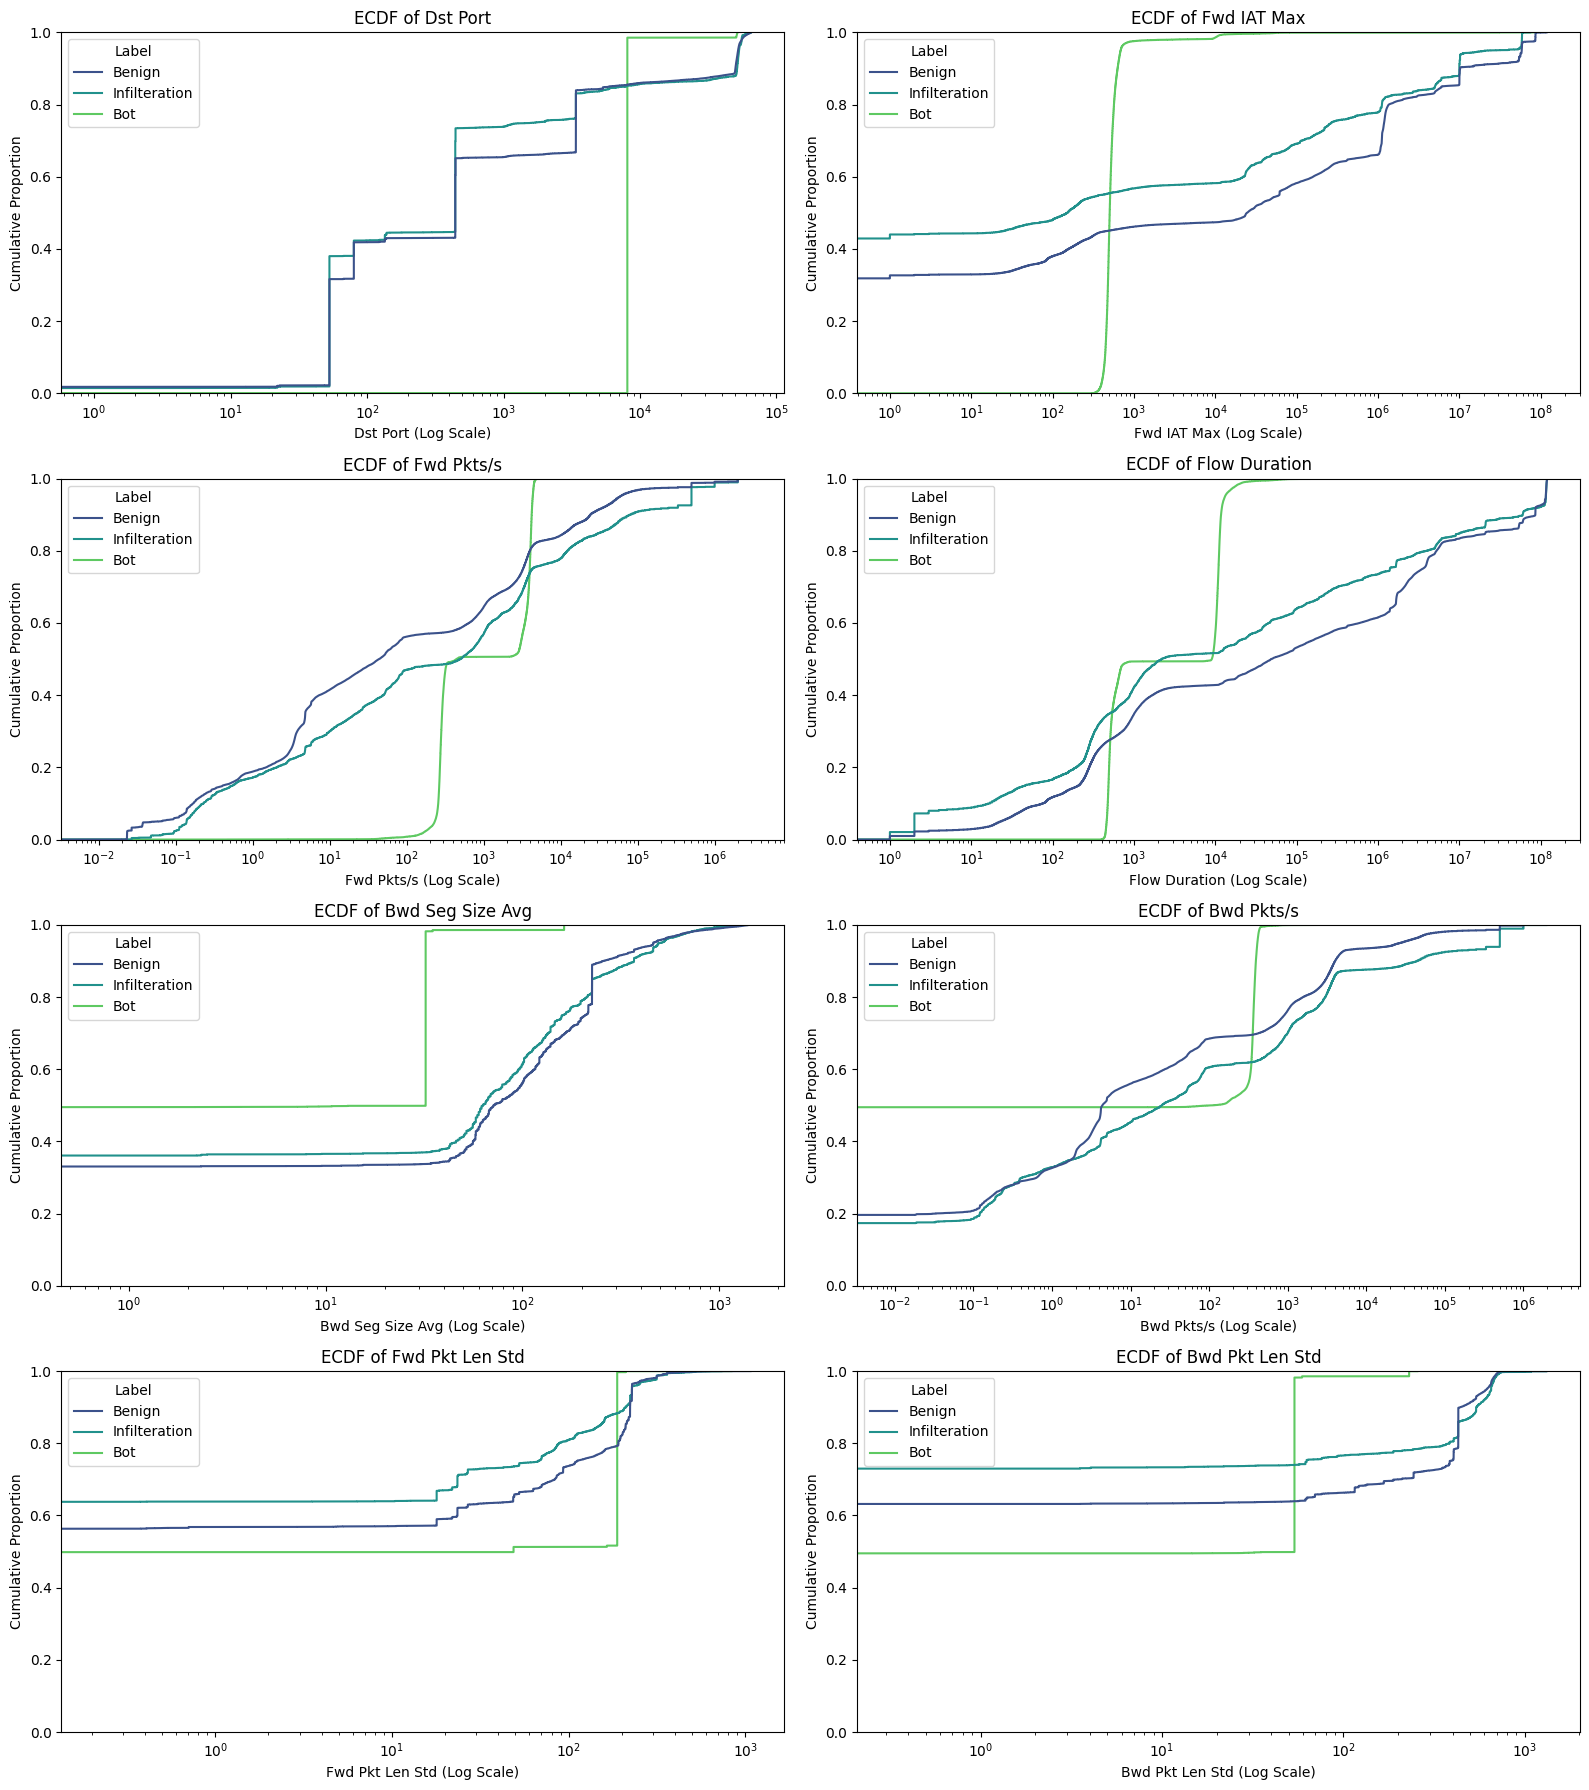

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns

print("Generating ECDFs for Top Behavioral Features...")

# Select the top timing and velocity features identified by the Random Forest
top_features = ["Dst Port", "Fwd IAT Max", "Fwd Pkts/s", "Flow Duration",
                "Bwd Seg Size Avg", "Bwd Pkts/s", "Fwd Pkt Len Std", "Bwd Pkt Len Std"]

# Take a 10% sample of the clean data to keep plotting fast and prevent Colab from crashing
df_sample = df_clean.select(["Label"] + top_features).sample(fraction=0.1, seed=42).toPandas()

# Set up the plotting grid
fig, axes = plt.subplots(4, 2, figsize=(16, 18)) # Changed from (3, 2) to (4, 2)
axes = axes.flatten()

for i, feature in enumerate(top_features):
    sns.ecdfplot(data=df_sample, x=feature, hue="Label", palette="viridis", ax=axes[i])
    axes[i].set_title(f"ECDF of {feature}")
    axes[i].set_xscale("log")
    axes[i].set_xlabel(f"{feature} (Log Scale)")
    axes[i].set_ylabel("Cumulative Proportion")

plt.tight_layout()
plt.show()

##### Step 2.2 More Insights

The ECDF plots visually validate the exact insights we extracted from our statistical summaries:

* **The Botnet's Robotic Precision**: The Bot traffic (green line) forms vertical "steps" across timing and volume features, visually proving scripted, fixed-interval behavior with zero human variance.

* **The Benign Human Variance**: Benign traffic (dark blue line) forms smooth, gradual curves, confirming natural human unpredictability and network latency.

* **The Infiltration Two-Stage Extremes**: While Infiltration (teal line) shows distinct steps in timing and velocity metrics, its curves for volume and variance (`Bwd Seg Size Avg`, `Bwd Pkt Len Std`) closely hug the Benign curves. This visually proves how Infiltration attacks blend their payload sizes into normal traffic to evade detection.

### Step 3: Feature Correlation (Collinearity Check)

Generating Feature Correlation Matrix (Collinearity Check)...


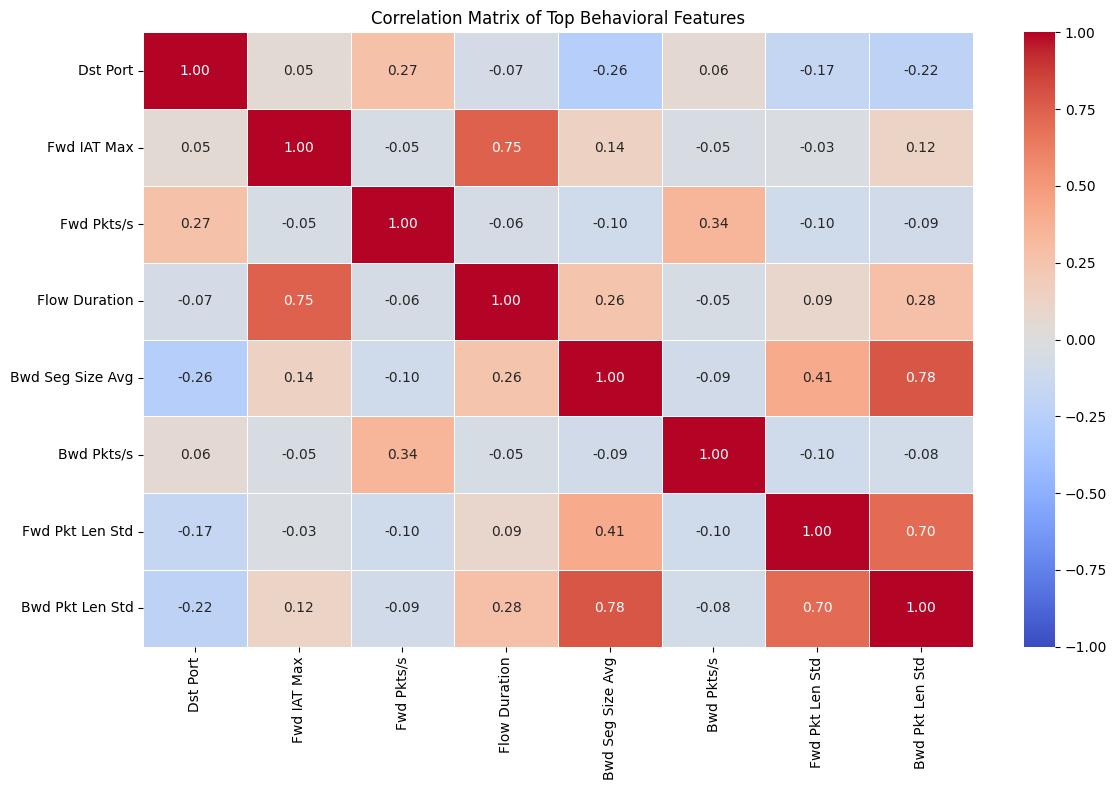

In [15]:
print("Generating Feature Correlation Matrix (Collinearity Check)...")

# The top numerical features we want to check for redundancy
top_numeric_features = ["Dst Port", "Fwd IAT Max", "Fwd Pkts/s", "Flow Duration",
                        "Bwd Seg Size Avg", "Bwd Pkts/s", "Fwd Pkt Len Std", "Bwd Pkt Len Std"]

# Extract a sample containing only these features
df_corr_sample = df_clean.select(top_numeric_features).sample(fraction=0.1, seed=42).toPandas()

# Calculate the Pearson correlation matrix
corr_matrix = df_corr_sample.corr()

# Plot the heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5, vmin=-1, vmax=1)
plt.title("Correlation Matrix of Top Behavioral Features")
plt.tight_layout()
plt.show()

#### Step 3 Insights

Our orthogonal feature selection strategy was highly successful. The correlation heatmap reveals that severe collinearity (redundancy $\ge$ 0.90) has been entirely eliminated. The highest correlations are between `Bwd Seg Size Avg` and `Bwd Pkt Len Std` (0.78), and `Fwd IAT Max` and `Flow Duration` (0.75). Because these fall well below the strict industry-standard threshold for removal in tree-based models, we can confidently proceed to modeling with all 8 features without the risk of overfitting

----

### Phase 2 Execution Complete: Final EDA Summary

Our Baseline Hunt is successfully complete. We transitioned from an unknown dataset of 80+ features to a highly targeted, orthogonal profile of 8 features:

* **Categorical Profiling**: Botnets utilize alternative channels (Port 8080), while Infiltration weaponizes standard web ports (443) to blend in.

* **Orthogonal Pre-Screening**: We successfully isolated the true mathematical signatures of an attack across Time, Velocity, Volume, and Variance pillars.

* **Visual Verification**: ECDFs mapped the robotic precision of Botnets and proved that Infiltration payloads actively mimic Benign volume distributions.

* **Collinearity Resolution**: Our targeted selection completely eliminated severe feature redundancy, clearing the path for robust machine learning.

We are now ready to mathematically validate these behavioral pillars through statistical inference..

# Inference

## Defining Hypotheses for Statistical Inference

To elevate our analysis from visual observation to absolute mathematical certainty, we must run formal statistical inference tests. Because our ECDFs and statistical summaries proved that our network data is heavily skewed and absolutely not normally distributed, we cannot use standard parametric tests like ANOVA. Instead, we will define our hypotheses below and test them using robust, non-parametric methods like the **Kruskal-Wallis H-test** and the **Mann-Whitney U test**.

<u>Hypothesis 1 (Connection Timing Rigidity)</u>:

* **$H0$ (Null)**: There is no statistically significant difference in the distribution of `Fwd IAT Max` across the traffic types.

* **$H1$ (Alternative)**: The maximum inter-arrival time differs significantly across traffic types, driven by robotic beacon intervals and extended exfiltration pauses.

<u>Hypothesis 2 (Payload Volume)</u>:

* **$H0$ (Null)**: There is no statistically significant difference in the distribution of `Bwd Seg Size Avg` between Benign, Botnet, and Infiltration traffic.

* **$H1$ (Alternative)**: At least one traffic type has a significantly different payload volume distribution due to automated C2 acknowledgments and stealthy data exfiltration.

In [19]:
from scipy import stats
import pandas as pd

print("--- Executing Statistical Inference Tests ---")

# 1. Extract a random sample of the top features to run tests in memory
# We take a 10% sample to ensure the tests run quickly without crashing the notebook
df_stats = df_clean.select("Label", "Fwd IAT Max", "Bwd Seg Size Avg").sample(fraction=0.1, seed=42).toPandas()

# 2. Separate the data by Traffic Type (Label)
benign_iat = df_stats[df_stats['Label'] == 'Benign']['Fwd IAT Max']
infiltration_iat = df_stats[df_stats['Label'] == 'Infilteration']['Fwd IAT Max']
bot_iat = df_stats[df_stats['Label'] == 'Bot']['Fwd IAT Max']

benign_bwd = df_stats[df_stats['Label'] == 'Benign']['Bwd Seg Size Avg']
infiltration_bwd = df_stats[df_stats['Label'] == 'Infilteration']['Bwd Seg Size Avg']
bot_bwd = df_stats[df_stats['Label'] == 'Bot']['Bwd Seg Size Avg']

# --- HYPOTHESIS 1: Fwd IAT Max ---
print("\nHypothesis 1 (Timing Rigidity: Fwd IAT Max)")
# Step 1: Kruskal-Wallis (Global difference check)
stat_kw_iat, p_kw_iat = stats.kruskal(benign_iat, infiltration_iat, bot_iat)
print(f"Kruskal-Wallis H-statistic: {stat_kw_iat:.2f}, p-value: {p_kw_iat}")

# Step 2: Mann-Whitney U (Pairwise check against Benign baseline)
stat_mw_inf_iat, p_mw_inf_iat = stats.mannwhitneyu(benign_iat, infiltration_iat, alternative='two-sided')
stat_mw_bot_iat, p_mw_bot_iat = stats.mannwhitneyu(benign_iat, bot_iat, alternative='two-sided')
print(f"Mann-Whitney (Benign vs Infiltration): U-statistic={stat_mw_inf_iat:.2f}, p-value={p_mw_inf_iat}")
print(f"Mann-Whitney (Benign vs Bot): U-statistic={stat_mw_bot_iat:.2f}, p-value={p_mw_bot_iat}")

print("=======================================================================")

# --- HYPOTHESIS 2: Bwd Seg Size Avg ---
print("\nHypothesis 2 (Payload Volume: Bwd Seg Size Avg)")
# Step 1: Kruskal-Wallis (Global difference check)
stat_kw_bwd, p_kw_bwd = stats.kruskal(benign_bwd, infiltration_bwd, bot_bwd)
print(f"Kruskal-Wallis H-statistic: {stat_kw_bwd:.2f}, p-value: {p_kw_bwd}")

# Step 2: Mann-Whitney U (Pairwise check against Benign baseline)
stat_mw_inf_bwd, p_mw_inf_bwd = stats.mannwhitneyu(benign_bwd, infiltration_bwd, alternative='two-sided')
stat_mw_bot_bwd, p_mw_bot_bwd = stats.mannwhitneyu(benign_bwd, bot_bwd, alternative='two-sided')
print(f"Mann-Whitney (Benign vs Infiltration): U-statistic={stat_mw_inf_bwd:.2f}, p-value={p_mw_inf_bwd}")
print(f"Mann-Whitney (Benign vs Bot): U-statistic={stat_mw_bot_bwd:.2f}, p-value={p_mw_bot_bwd}")

--- Executing Statistical Inference Tests ---

Hypothesis 1 (Timing Rigidity: Fwd IAT Max)
Kruskal-Wallis H-statistic: 855.16, p-value: 2.019487236334319e-186
Mann-Whitney (Benign vs Infiltration): U-statistic=376241184.00, p-value=3.1125332368569017e-78
Mann-Whitney (Benign vs Bot): U-statistic=1515762228.00, p-value=1.459129002954197e-124

Hypothesis 2 (Payload Volume: Bwd Seg Size Avg)
Kruskal-Wallis H-statistic: 15002.47, p-value: 0.0
Mann-Whitney (Benign vs Infiltration): U-statistic=344327226.50, p-value=2.1664850033799535e-09
Mann-Whitney (Benign vs Bot): U-statistic=2054668171.50, p-value=0.0


## Mathematical Validation of Behavioral Signatures

Our non-parametric statistical tests provide absolute mathematical certainty that the behavioral differences we observed are not random anomalies.

* **Global Significance (Kruskal-Wallis)**: The H-tests for both `Fwd IAT Max` (Timing Rigidity) and `Bwd Seg Size Avg` (Payload Volume) returned extreme statistics (`H=855.16` and `H=15002.47`) with p-values effectively at zero (`2.01e-186` and `0.0`, respectively). This allows us to definitively reject both null hypotheses, proving that maximum connection latency and payload volume vary significantly across the entire dataset based on traffic type.

* **Pairwise Proof (Mann-Whitney U)**: When tested directly against the Benign baseline, both Infiltration and Botnet traffic returned infinitesimally small p-values across both metrics (ranging from `2.16e-09` down to exactly `0.0`). This mathematically proves that the robotic beaconing of Botnets (zero-variance timing and payload) and the stealthy volume/two-stage timing of Infiltration attacks are statistically distinct, separate populations from normal human traffic.

------

# Phase 2 Completion: Key Learnings & Modeling Handoff

Our Exploratory Data Analysis successfully translated raw network telemetry into a structured, mathematically validated threat profile using an orthogonal feature selection strategy.

**What we learned**:

1. **Categorical Evasion**: Botnets utilize alternative channels (e.g., Port 8080), while Infiltration attacks weaponize standard web ports (e.g., 443, 80) to bypass firewalls and blend in.

2. **Orthogonal Signatures**: By expanding our analysis across Time, Velocity, Volume, and Variance, we built a 360-degree attack profile. We eliminated data leakage (like OS-specific window bytes) and discarded heavily correlated, redundant noise.

3. **Behavioral Extremes**: ECDF plots visually confirmed that cyberattacks do not follow normal distributions. Botnets exhibit zero-variance robotic precision in both timing and volume, while Infiltration attacks show extreme two-stage variance in timing while stealthily matching the Benign baseline in payload volume.

4. **Statistical Certainty**: Non-parametric tests proved our findings with 100% statistical significance, confirming that our selected features mathematically separate the traffic classes.

# What we are taking to Notebook 3 (Data Modeling):

* **Filtered Feature Set**: We are bringing forward our finalized 8 features (`Dst Port`, `Fwd IAT Max`, `Fwd Pkts/s`, `Flow Duration`, `Bwd Seg Size Avg`, `Bwd Pkts/s`, `Fwd Pkt Len Std`, `Bwd Pkt Len Std`). This subset is free of severe collinearity (`0.90+`) , devoid of data leakage, and packed with robust, orthogonal behavioral signals.

* **Model Selection & Architecture**: Because our data is massively imbalanced, highly skewed, and non-parametric, standard linear algorithms will fail. We will deploy robust tree-based models—specifically utilizing a **Hierarchical XGBoost Architecture** (Stage 1: Normal vs. Anomaly, Stage 2: Bot vs. Infiltration) to prevent the models from confusing stealthy attacks with noisy clusters..

* **Baseline Thresholds**: The exact statistical medians and behavioral profiles we uncovered will serve as our baseline to evaluate if our ML models are actually learning the correct threat patterns, rather than just blindly guessing "Benign" due to the massive class imbalance.